In [1]:
import cvxpy as cp
import numpy as np
import math
import random

class GridWorld:
    def __init__(self,d,size=8,danger=[7,1],goal=[4,5],wall=[2,5],coins=[(1,6),(4,2),(5,5)], horizon=50):
        self.noise = None
        self.d=d
        self.size = size
        self.horizon = horizon
        self.goal = tuple(goal)
        self.danger = tuple(danger)
        self.wall = tuple(wall)
        self._init_coins = tuple(map(tuple, coins)) 
        self.coins = set(self._init_coins)
        self.collected_coins = set()
        self.collected = 0
        self.done = 0
        self.sparse = False
        self.pos = (0,7)
        self.t = 0
        self.time_weight = 1
        self.state_weight = {}
        for i in range(8):
            for j in range(8):
                self.state_weight[(i,j)] = 1
    
    def reset(self):
        self.done = 0
        self.pos = (0,7)
        self.t = 0
        self.collected = 0
        self.collected_coins = set()
        self.coins = set(self._init_coins)
        return self.pos
    
    def step(self, intended_action):
        probs = np.full(4, 0.03)
        probs[intended_action] = 0.91
        action = np.random.choice(4, p=probs)
        x, y = self.pos
        if action == 0: x = max(0, x-1)       # up
        if action == 1: x = min(self.size-1, x+1) # down
        if action == 2: y = max(0, y-1)       # left
        if action == 3: y = min(self.size-1, y+1) # right
        if((x,y)!=(self.wall)):
            self.pos = (x,y)
        if self.pos in self.coins:
            self.collected += 1
            self.collected_coins.add(self.pos)
            self.coins.remove(self.pos)
        self.t += 1
        self.done = ((self.t >= self.horizon)or (self.pos==self.goal) or (self.pos==self.danger))
        return self.pos, self.done
    
    def immediate_reward(self):
        return self.state_weight[self.pos]*(1-int(self.pos==self.danger))*(1+1.5*(self.pos==self.goal)-self.time_weight/self.horizon)

#     def true_return(self):
#         weights = [0.1, 1.0, 2.0, 3.0]
#         if(self.sparse==False):
#             true_reward = 2*(1-(self.pos==self.danger))*(weights[self.collected]*(self.collected + 1.32*(self.pos==self.goal)) - 5*(self.t-14)/self.horizon + 5*36/50)
#         else:
#             true_reward = (1-(self.pos==self.danger))*(weights[self.collected]*(self.collected + 1.32*(self.pos==self.goal)))
#         return true_reward
    
#     def get_feedback(self):
#         r_true = self.true_return()
#         if np.random.rand() < 1 - self.noise:
#             return r_true
#         else:
#             if(not self.sparse):
#                 return np.random.uniform(0.0,32)
#             else:
#                 return np.random.uniform(0.0,12.96)
        

def softmax(logits):
    exps = np.exp(logits - np.max(logits))
    return exps / np.sum(exps)

class Policy:
    def __init__(self, grid_size, action_dim):
        self.grid_size = grid_size
        self.state_dim = grid_size * grid_size
        self.action_dim = action_dim
        self.theta = np.ones((self.state_dim, self.action_dim))
    
    def state_index(self, state):
        return state[0] * self.grid_size + state[1]
    
    def act(self, state):
        s_idx = self.state_index(state)
        probs = softmax(self.theta[s_idx])
        action = np.random.choice(len(probs), p=probs)
        return action, probs
    
    def grad_log_prob(self, state, action):
        """Return (state_index, grad_row) with grad_row shape (action_dim,)
           grad_row[j] = 1{j==action} - pi(j|s)"""
        s_idx = self.state_index(state)
        probs = softmax(self.theta[s_idx])
        grad_row = -probs.copy()
        grad_row[action] += 1.0
        return s_idx, grad_row
    


###----------Traning loop-------------###
def train(m=50,eta=0.5,epsilon=0.1,grid_size=8,danger=[7,1],goal=[4,5],wall=[2,5],horizon=50,coins=None,seed=0,noise=0.1,threshold=16,sparse=False):
    np.random.seed(seed)
    queries = 0                             
    if coins is None:
        coins=[(1,6),(4,2),(5,5)]
    d = 4+len(coins)
    env = GridWorld(d,size=grid_size, danger=danger, goal=goal, wall=wall, coins=coins, horizon=horizon)
    policy = Policy(grid_size=grid_size, action_dim=4)
    
    env.sparse = sparse
    env.noise = noise
    R_max = 31
    if(sparse): R_max = 12.5
    flag = 0
    average_returns = []
    steps = 0
    for h in range(1):
        if(flag): break
        for g in range(15000):
            steps+=1
            returns = []
            labels = []
            rollout_trajectories = []
            for i in range(m): ## sample trajectories under current policy pi to approiximate the theoretical expectation
                s = env.reset()
                traj = {"states": [], "actions": [], "steps":0, "coins":0}
                done = False
                y = 0
                while not done:
                    y += env.immediate_reward()
                    a, _ = policy.act(s)
                    traj["states"].append(s)
                    traj["actions"].append(a)
                    s, done = env.step(a)

                traj["steps"] = env.horizon
                traj["coins"] = env.collected
#                 y = env.get_feedback()
                queries+=1
#                 returns.append(env.true_return())
                labels.append(y)
                rollout_trajectories.append((traj, y))
            if(g%100==0):
                print(g)
#                 print(f"average reward: {np.mean(returns)}")
                print(f"average feedback: {np.mean(labels)}")
            average_returns.append(np.mean(returns))
            if(np.mean(returns)>R_max):
                flag = 1
                break            
            
                ## now with these m rollouts, approximate the expectation of estimated reward under policy pi
            grad_theta = np.zeros_like(policy.theta)
            R_hats = [y for _, y in rollout_trajectories]
            b = float(np.mean(R_hats))  # baseline

            for (traj,y), r_hat in zip(rollout_trajectories,R_hats):

                temp = r_hat-b

                for state,action in zip(traj["states"],traj["actions"]):
                    s_idx, grad_row = policy.grad_log_prob(state, action)
                    grad_theta[s_idx] += grad_row*(temp)

            grad_theta = grad_theta/len(rollout_trajectories)
            policy.theta += eta*grad_theta


                      

    return policy,queries,steps,average_returns


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Numerically safe softmax
# ---------------------------------
def softmax(logits):
    logits = np.asarray(logits, dtype=np.float64)
    exps = np.exp(logits - np.max(logits))
    probs = exps / np.sum(exps)
    probs = probs / np.sum(probs)  # extra normalization for safety

    if not np.isclose(np.sum(probs), 1.0, atol=1e-10):
        raise ValueError(f"Softmax probabilities do not sum to 1. Sum = {np.sum(probs)}")
    return probs


# ---------------------------------
# Randomly initialized policy
# ---------------------------------
class RandomInitPolicy:
    def __init__(self, grid_size, action_dim, init_scale=0.5, seed=None):
        self.grid_size = grid_size
        self.state_dim = grid_size * grid_size
        self.action_dim = action_dim
        rng = np.random.default_rng(seed)
        self.theta = rng.normal(0.0, init_scale, size=(self.state_dim, self.action_dim))

    def state_index(self, state):
        return state[0] * self.grid_size + state[1]

    def act(self, state):
        s_idx = self.state_index(state)
        probs = softmax(self.theta[s_idx])

        if not np.isclose(probs.sum(), 1.0, atol=1e-10):
            raise ValueError(f"Action probabilities do not sum to 1: {probs.sum()}")

        action = np.random.choice(self.action_dim, p=probs)
        return action, probs


# ---------------------------------
# One rollout return
# ---------------------------------
def rollout_once(env, policy):
    s = env.reset()
    done = False
    while not done:
        a, _ = policy.act(s)
        s, done = env.step(a)
    return env.true_return()


# ---------------------------------
# Returns from one policy
# ---------------------------------
def sample_policy_returns(policy, env_kwargs, n_episodes=300):
    env = GridWorld(
        d=4 + len(env_kwargs["coins"]),
        size=env_kwargs["grid_size"],
        danger=env_kwargs["danger"],
        goal=env_kwargs["goal"],
        wall=env_kwargs["wall"],
        coins=env_kwargs["coins"],
        horizon=env_kwargs["horizon"]
    )
    env.sparse = env_kwargs["sparse"]
    env.noise = 0.0

    returns = []
    for _ in range(n_episodes):
        returns.append(rollout_once(env, policy))
    return np.array(returns)


# ---------------------------------
# Simple Gaussian KDE from scratch
# ---------------------------------
def gaussian_kde_manual(samples, x_grid, bandwidth=None):
    samples = np.asarray(samples, dtype=np.float64)
    n = len(samples)

    if n < 2:
        raise ValueError("Need at least 2 samples for KDE")

    # Silverman's rule of thumb
    if bandwidth is None:
        std = np.std(samples, ddof=1)
        iqr = np.percentile(samples, 75) - np.percentile(samples, 25)
        sigma = min(std, iqr / 1.34) if iqr > 0 else std
        if sigma <= 1e-12:
            sigma = max(std, 1.0)
        bandwidth = 0.9 * sigma * n ** (-1/5)
        bandwidth = max(bandwidth, 1e-3)

    u = (x_grid[:, None] - samples[None, :]) / bandwidth
    kernel_vals = np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
    density = np.mean(kernel_vals, axis=1) / bandwidth
    return density


# ---------------------------------
# Plot smooth return densities
# ---------------------------------
def plot_policy_return_distributions(
    n_policies=5,
    n_episodes_per_policy=400,
    grid_size=8,
    danger=[7,1],
    goal=[4,5],
    wall=[2,5],
    horizon=50,
    coins=[(1,6),(4,2),(5,5)],
    sparse=False,
    init_scale=0.5,
    base_seed=0
):
    env_kwargs = {
        "grid_size": grid_size,
        "danger": danger,
        "goal": goal,
        "wall": wall,
        "horizon": horizon,
        "coins": coins,
        "sparse": sparse,
    }

    all_returns = []

    for k in range(n_policies):
        policy = RandomInitPolicy(
            grid_size=grid_size,
            action_dim=4,
            init_scale=init_scale,
            seed=base_seed + k
        )
        rets = sample_policy_returns(policy, env_kwargs, n_episodes=n_episodes_per_policy)
        all_returns.append(rets)

    # Common x-axis for all KDEs
    all_samples = np.concatenate(all_returns)
    x_min = np.min(all_samples) - 1.0
    x_max = np.max(all_samples) + 1.0
    x_grid = np.linspace(x_min, x_max, 600)

    plt.figure(figsize=(10, 6))

    for i, rets in enumerate(all_returns):
        density = gaussian_kde_manual(rets, x_grid)
        plt.plot(x_grid, density, linewidth=2, label=f"Policy {i+1}")
        plt.fill_between(x_grid, density, alpha=0.15)

        # optional: mark sample mean
        plt.axvline(np.mean(rets), linestyle='--', alpha=0.5)

    plt.xlabel("Return")
    plt.ylabel("Estimated density")
    plt.title("Smooth return distributions for randomly initialized policies")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return all_returns

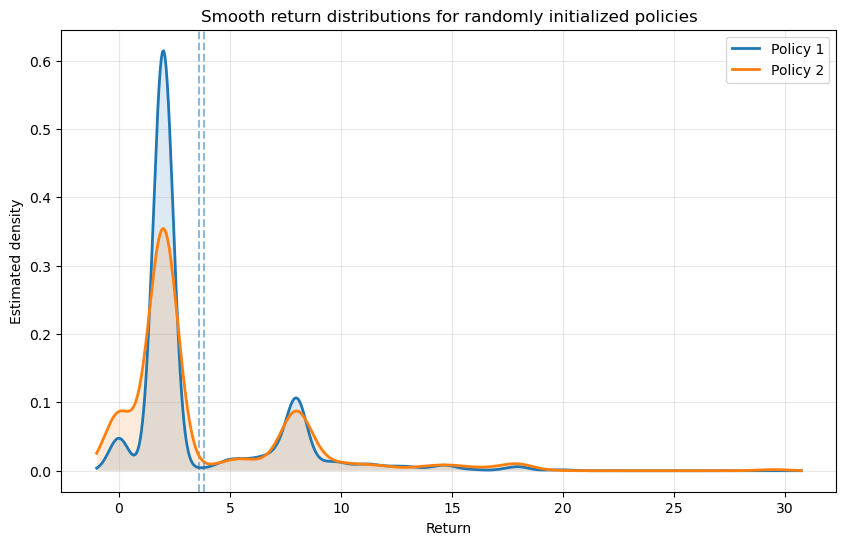

In [33]:
all_returns = plot_policy_return_distributions(
    n_policies=2,
    n_episodes_per_policy=1000,
    init_scale=1,
    sparse=False,
    base_seed=14
)